# EDA with Red Wine Dataset

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. The goal is to model wine quality based on physicochemical tests. For more details, consult: http://www.vinhoverde.pt/en/ or the reference [Cortez et al., 2009].  Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).


These datasets can be viewed as classification or regression tasks.  The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection 

Input variables (based on physicochemical tests):

   1 - fixed acidity

   2 - volatile acidity

   3 - citric acid

   4 - residual sugar

   5 - chlorides

   6 - free sulfur dioxide

   7 - total sulfur dioxide

   8 - density

   9 - pH

   10 - sulphates

   11 - alcohol
   
   Output variable (based on sensory data): 

   12 - quality (score between 0 and 10)

## 1) Problem Statement

This project understands how the quality of red wine is influenced by its physicochemical attributes.

## 2) Loading Data and Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("wine_quality_red.csv",sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3) Characteristics of Data

In [3]:
df.shape

(1599, 12)

The dataset contains 1599 rows and 12 columns. The columns are:

In [4]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

Datatypes of columns:-

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Statistical Description of numerical data:-

In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### 3.1. Check Missing Values

In [7]:
# No Missing values
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

### 3.2. Check Duplicates

In [8]:
df.duplicated().sum()   #240 duplicate records

240

In [9]:
df[df.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


In [10]:
df.drop_duplicates(inplace=True)    #Dropping duplicates

In [11]:
df.shape   #Duplicates removed

(1359, 12)

### 3.3. Check unique values of each column

In [12]:
df.nunique()   #Checking unique values in each column

fixed acidity            96
volatile acidity        143
citric acid              80
residual sugar           91
chlorides               153
free sulfur dioxide      60
total sulfur dioxide    144
density                 436
pH                       89
sulphates                96
alcohol                  65
quality                   6
dtype: int64

In [13]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3], dtype=int64)

Above are 6 unique quality scores

In [ ]:
d = df['quality'].value_counts().to_dict()
d

{5: 577, 6: 535, 7: 167, 4: 53, 8: 17, 3: 10}

([<matplotlib.patches.Wedge at 0x24e4506c0b0>,
 [Text(0.25821137483255596, 1.0692646472726393, '5'),
  Text(-0.7951496098451692, -0.7600901906767876, '6'),
  Text(0.800401816489204, -0.754557441259963, '7'),
  Text(1.0665207655922797, -0.26932036046399827, '4'),
  Text(1.095978743575482, -0.09397123831634843, '8'),
  Text(1.0997060979325133, -0.0254263282847884, '3')],
 [Text(0.14084256809048507, 0.5832352621487122, '42.5%'),
  Text(-0.43371796900645593, -0.4145946494600659, '39.4%'),
  Text(0.4365828089941112, -0.411576786141798, '12.3%'),
  Text(0.5817385994139707, -0.14690201479854448, '3.9%'),
  Text(0.5978065874048083, -0.05125703908164459, '1.3%'),
  Text(0.5998396897813708, -0.013868906337157308, '0.7%')])

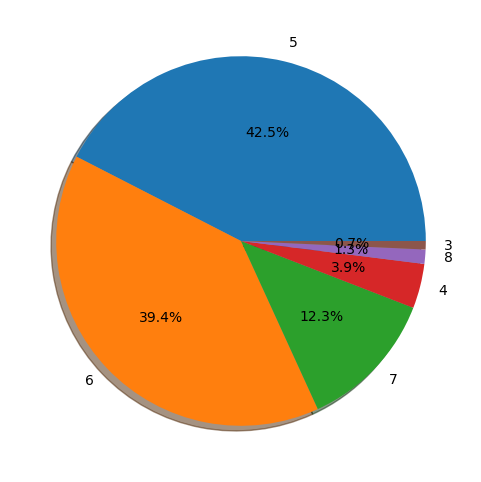

In [ ]:
plt.figure(figsize=(15,6))
plt.pie(d.values(),labels=d.keys(),autopct="%1.1f%%",shadow=True)

The data is imbalanced! Majority of data is skewed towards quality scores of 5-6.

## 4) Exploring data

By observing the dataset, we can easily see all the features are numerical with no categorical features.

### 4.1. Finding out distribution in each numerical column

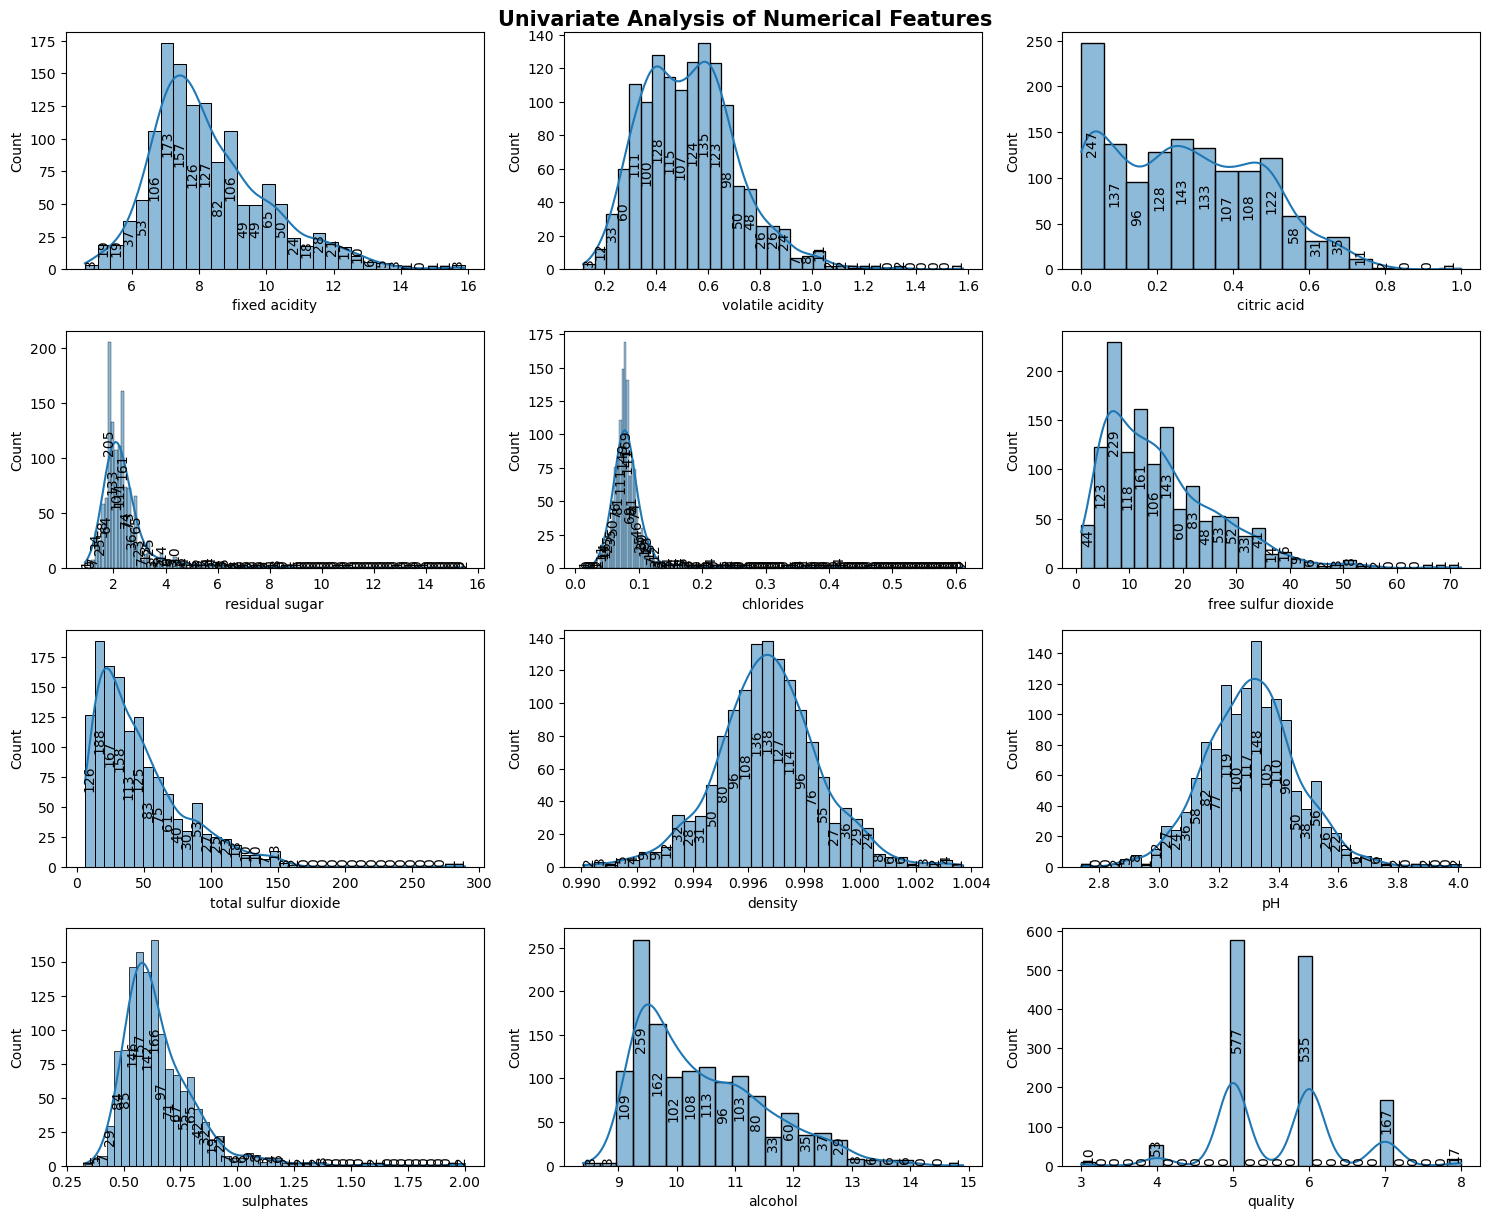

In [17]:
plt.figure(figsize=(15,15))
plt.suptitle("Univariate Analysis of Numerical Features",fontsize=15,fontweight='bold')

num_features = df.columns.tolist()

for i in range(0,len(num_features)):
    plt.subplot(5,3,i+1)

    ax = sns.histplot(df[num_features[i]],kde=True)

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', 
                    (p.get_x() + p.get_width() / 2., height / 2),
                    ha='center', va='bottom', rotation = 90, fontsize=10)

    plt.xlabel(num_features[i])
    plt.tight_layout()
plt.show()

### 4.2. Detecting Outliers

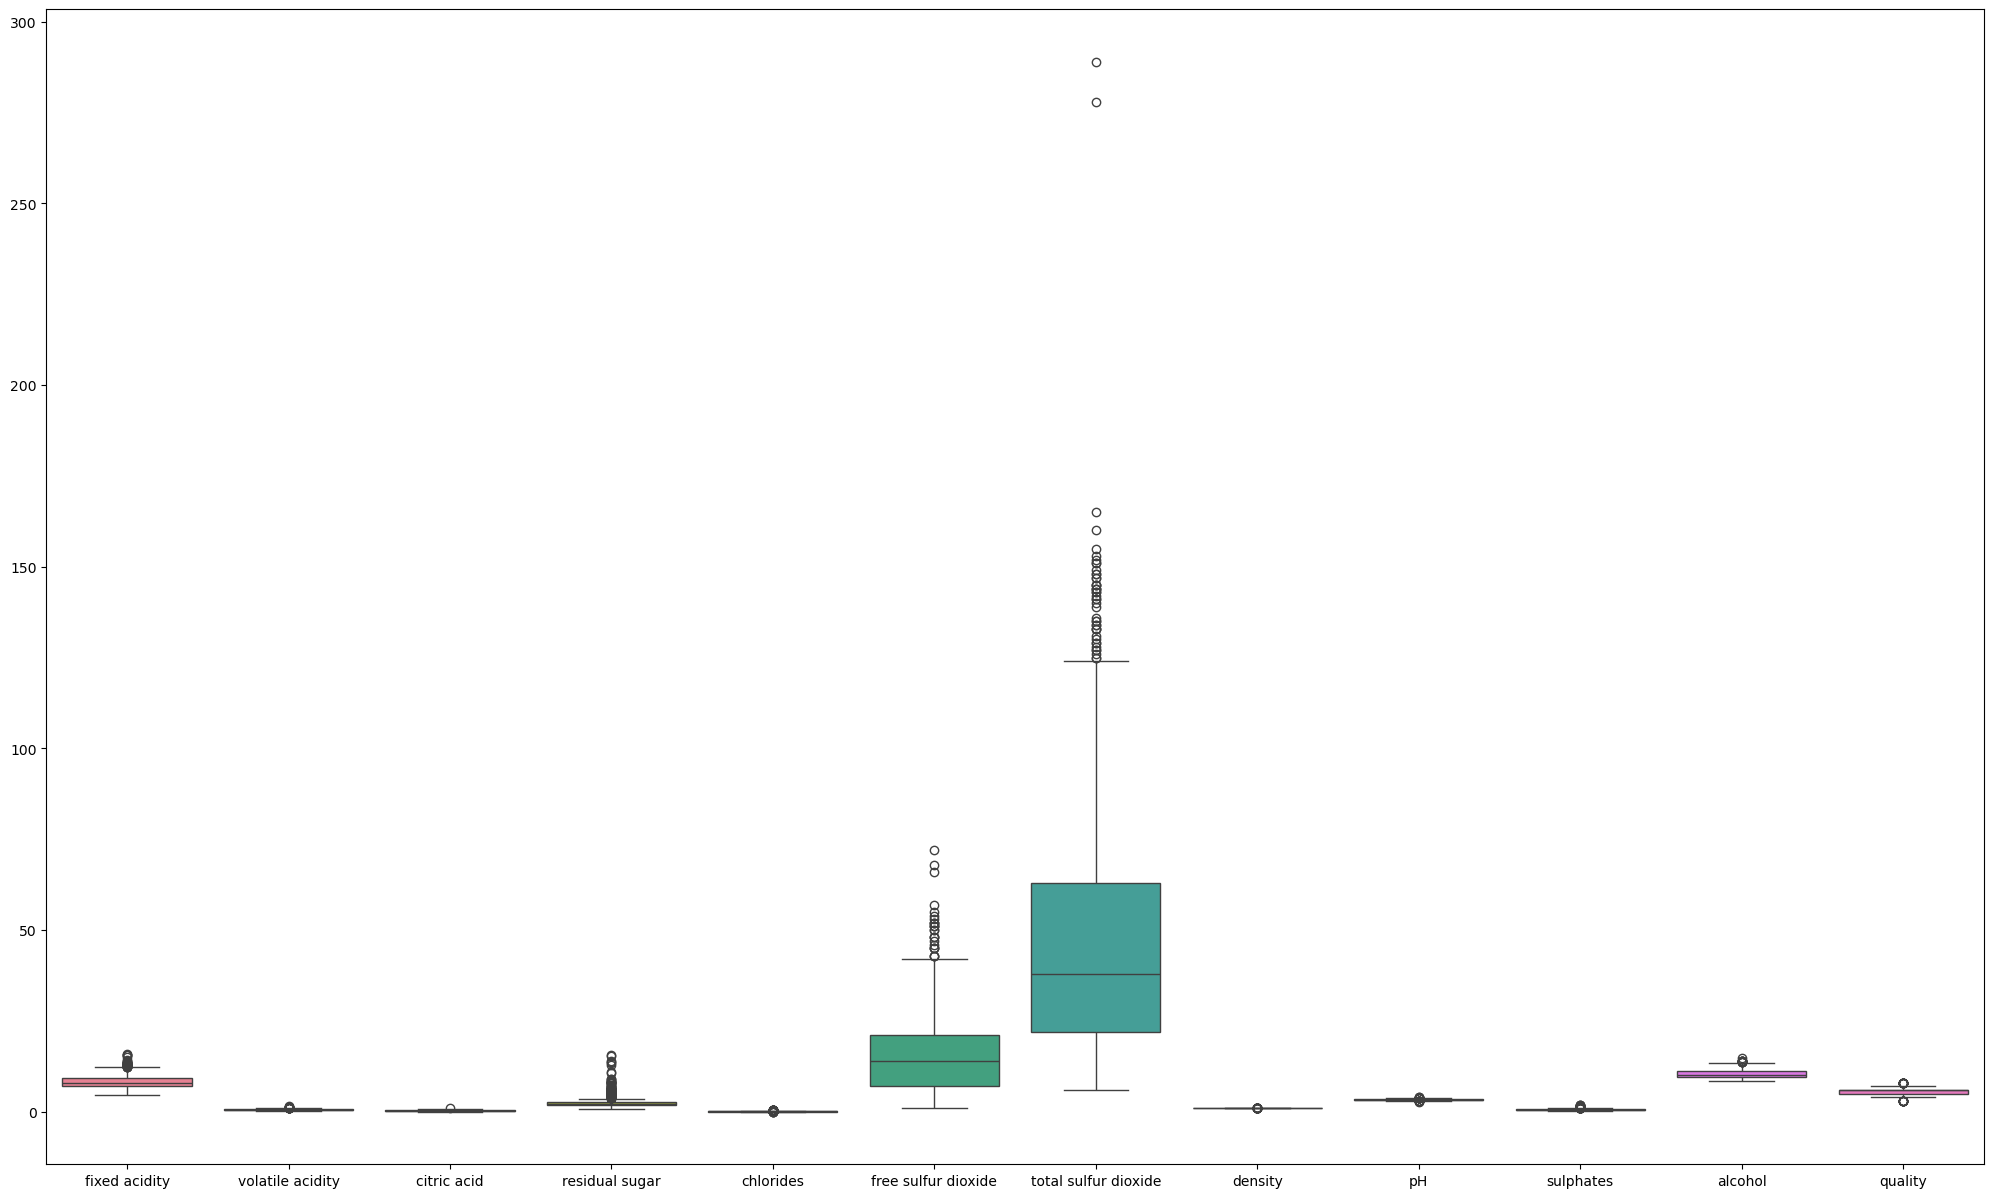

In [26]:
# Visualizing Outliers of each column from boxplot
plt.figure(figsize=(25,15))
sns.boxplot(df)
plt.show()

Thus, outliers are present in data and features of 'residual sugar', 'free sulphur dioxide', 'total sulphur dioxide' are mostly affected by outliers.

### 4.3. Influence of physicochemical features on quality of wine

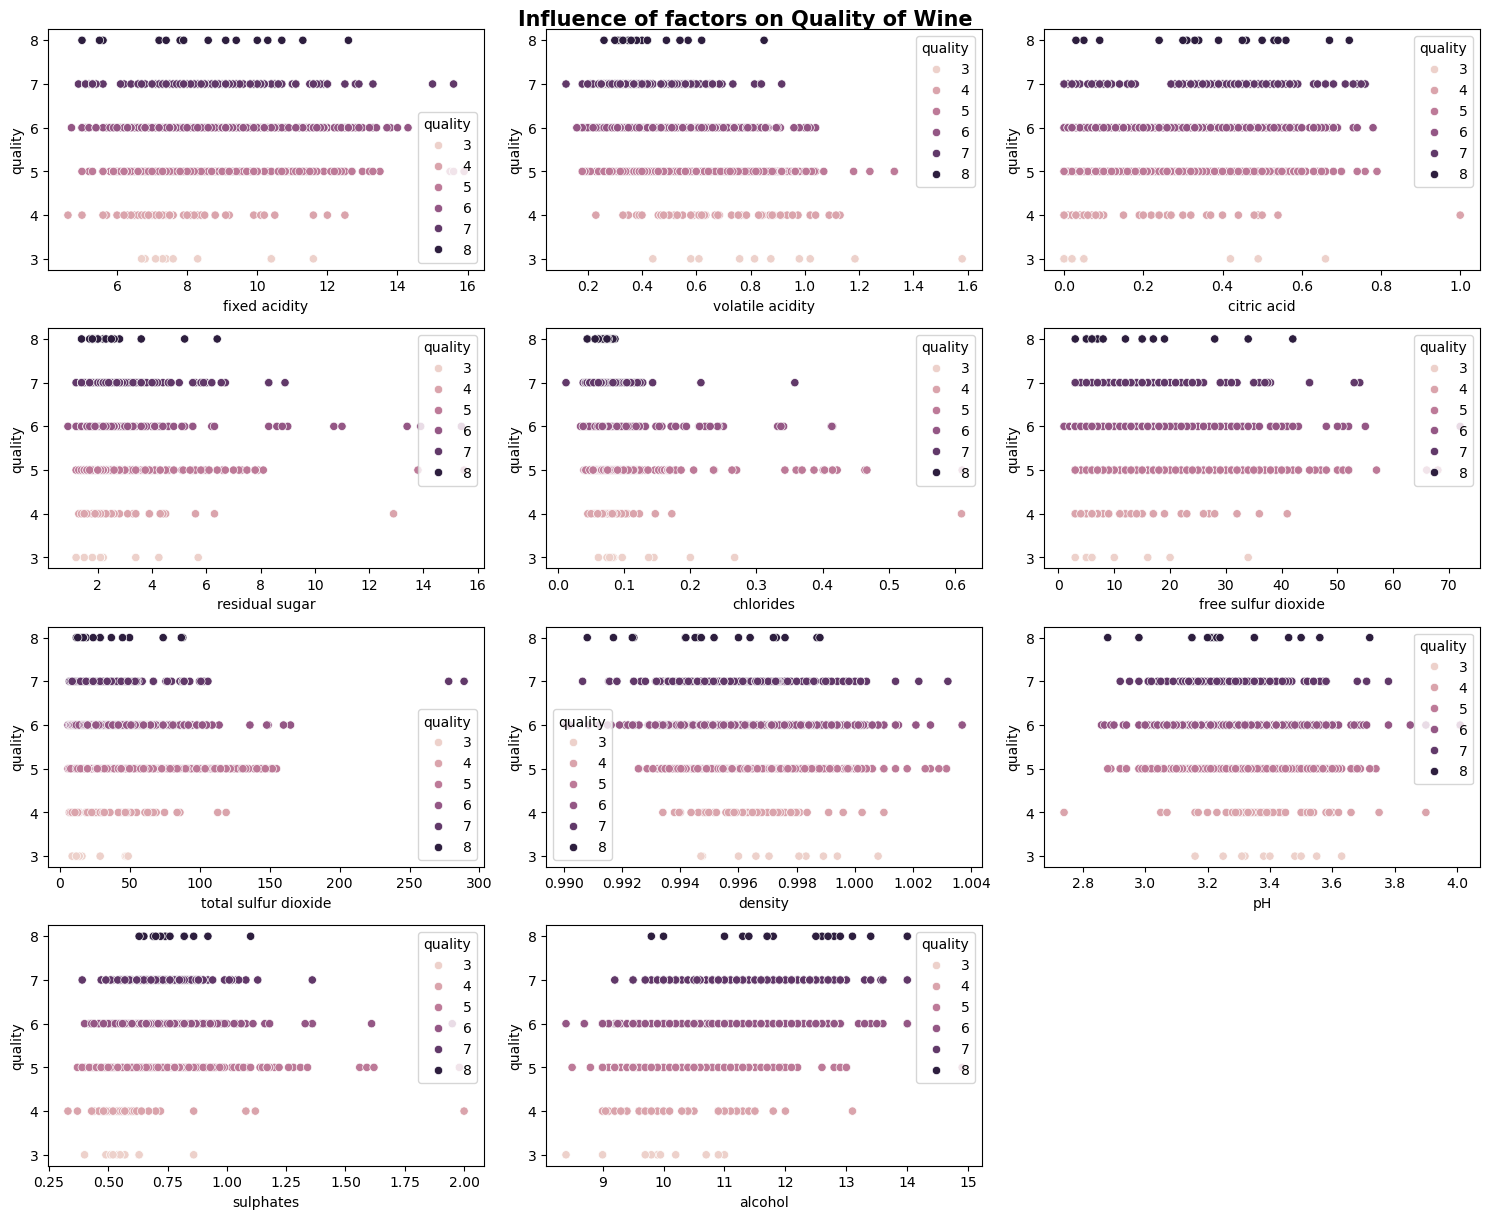

In [36]:
plt.figure(figsize=(15,15))
plt.suptitle("Influence of factors on Quality of Wine",fontsize=15,fontweight='bold')

factors = num_features[:-1]

for i in range(0,len(factors)):
    plt.subplot(5,3,i+1)

    sns.scatterplot(data = df, x = df[factors[i]], y = df['quality'], hue = df['quality'])

    plt.xlabel(factors[i])
    plt.tight_layout()

plt.show()

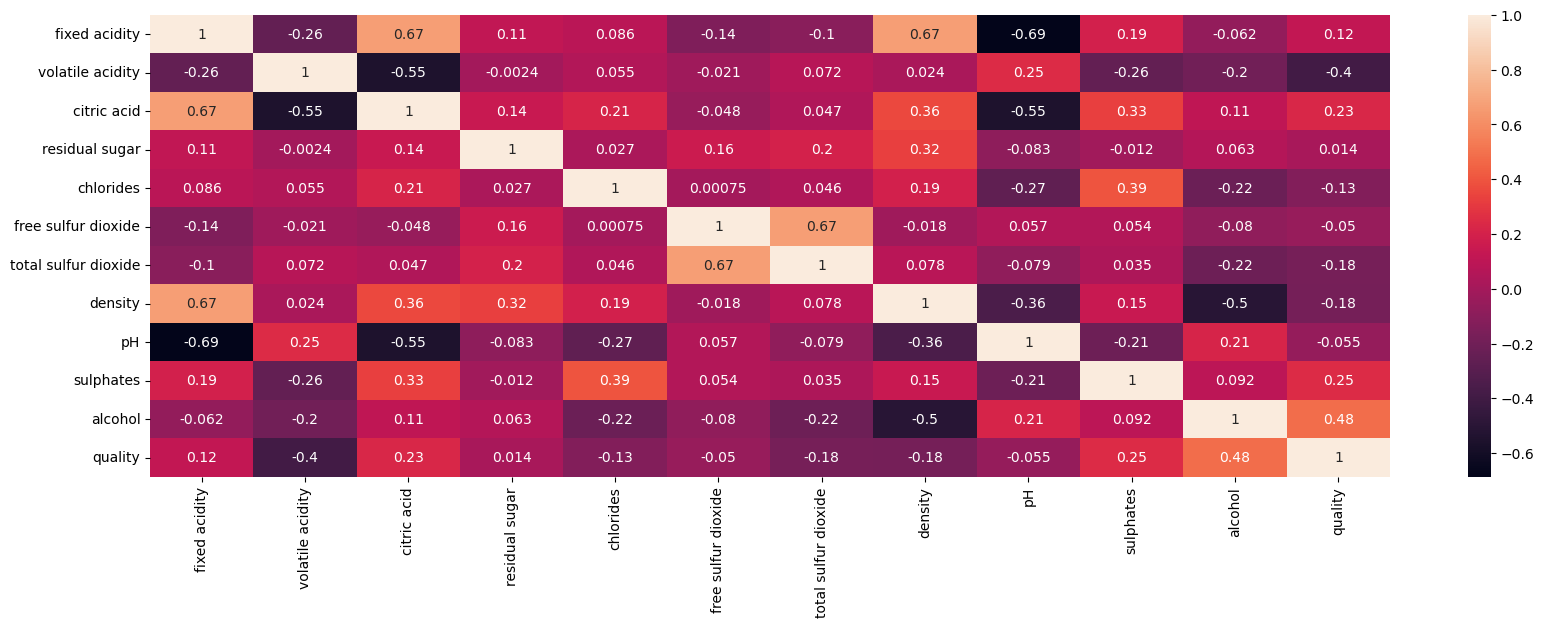

In [ ]:
# Visualise correlation
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,6))
sns.heatmap(df.corr(),annot=True)
plt.show()

Insights:-

1. From the heatmap, 'alcohol', 'sulphates', 'citric acid' and 'fixed acidity' show positive correlations with wine quality (in descending order of magnitude of positive correlation)
2. On contrary, features - 'volatile acidity', 'total sulphur dioxide', 'density', 'chlorides' show negative correlations with wine quality, along with 'residual sugar', 'free sulphur dioxide' and 'pH' showing almost zero correlations

### 4.4. Alcohol levels determining quality

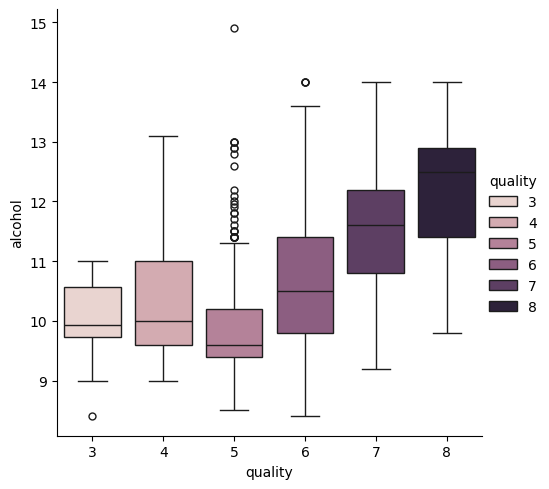

In [39]:
sns.catplot(data=df, y='alcohol', x='quality',kind='box',hue='quality')
plt.show()

In [42]:
median_alcohol_by_quality = df.groupby('quality')['alcohol'].median()
print("Median alcohol level by quality scores:- \n",median_alcohol_by_quality)

Median alcohol level by quality scores:- 
 quality
3     9.925
4    10.000
5     9.600
6    10.500
7    11.600
8    12.500
Name: alcohol, dtype: float64


Insight:- With gradually increasing alcohol level, the quality score of red wine increases, except in case of quality score 5 whose result is opposite to what we are suggesting.

### 4.5. Multivariate Analysis

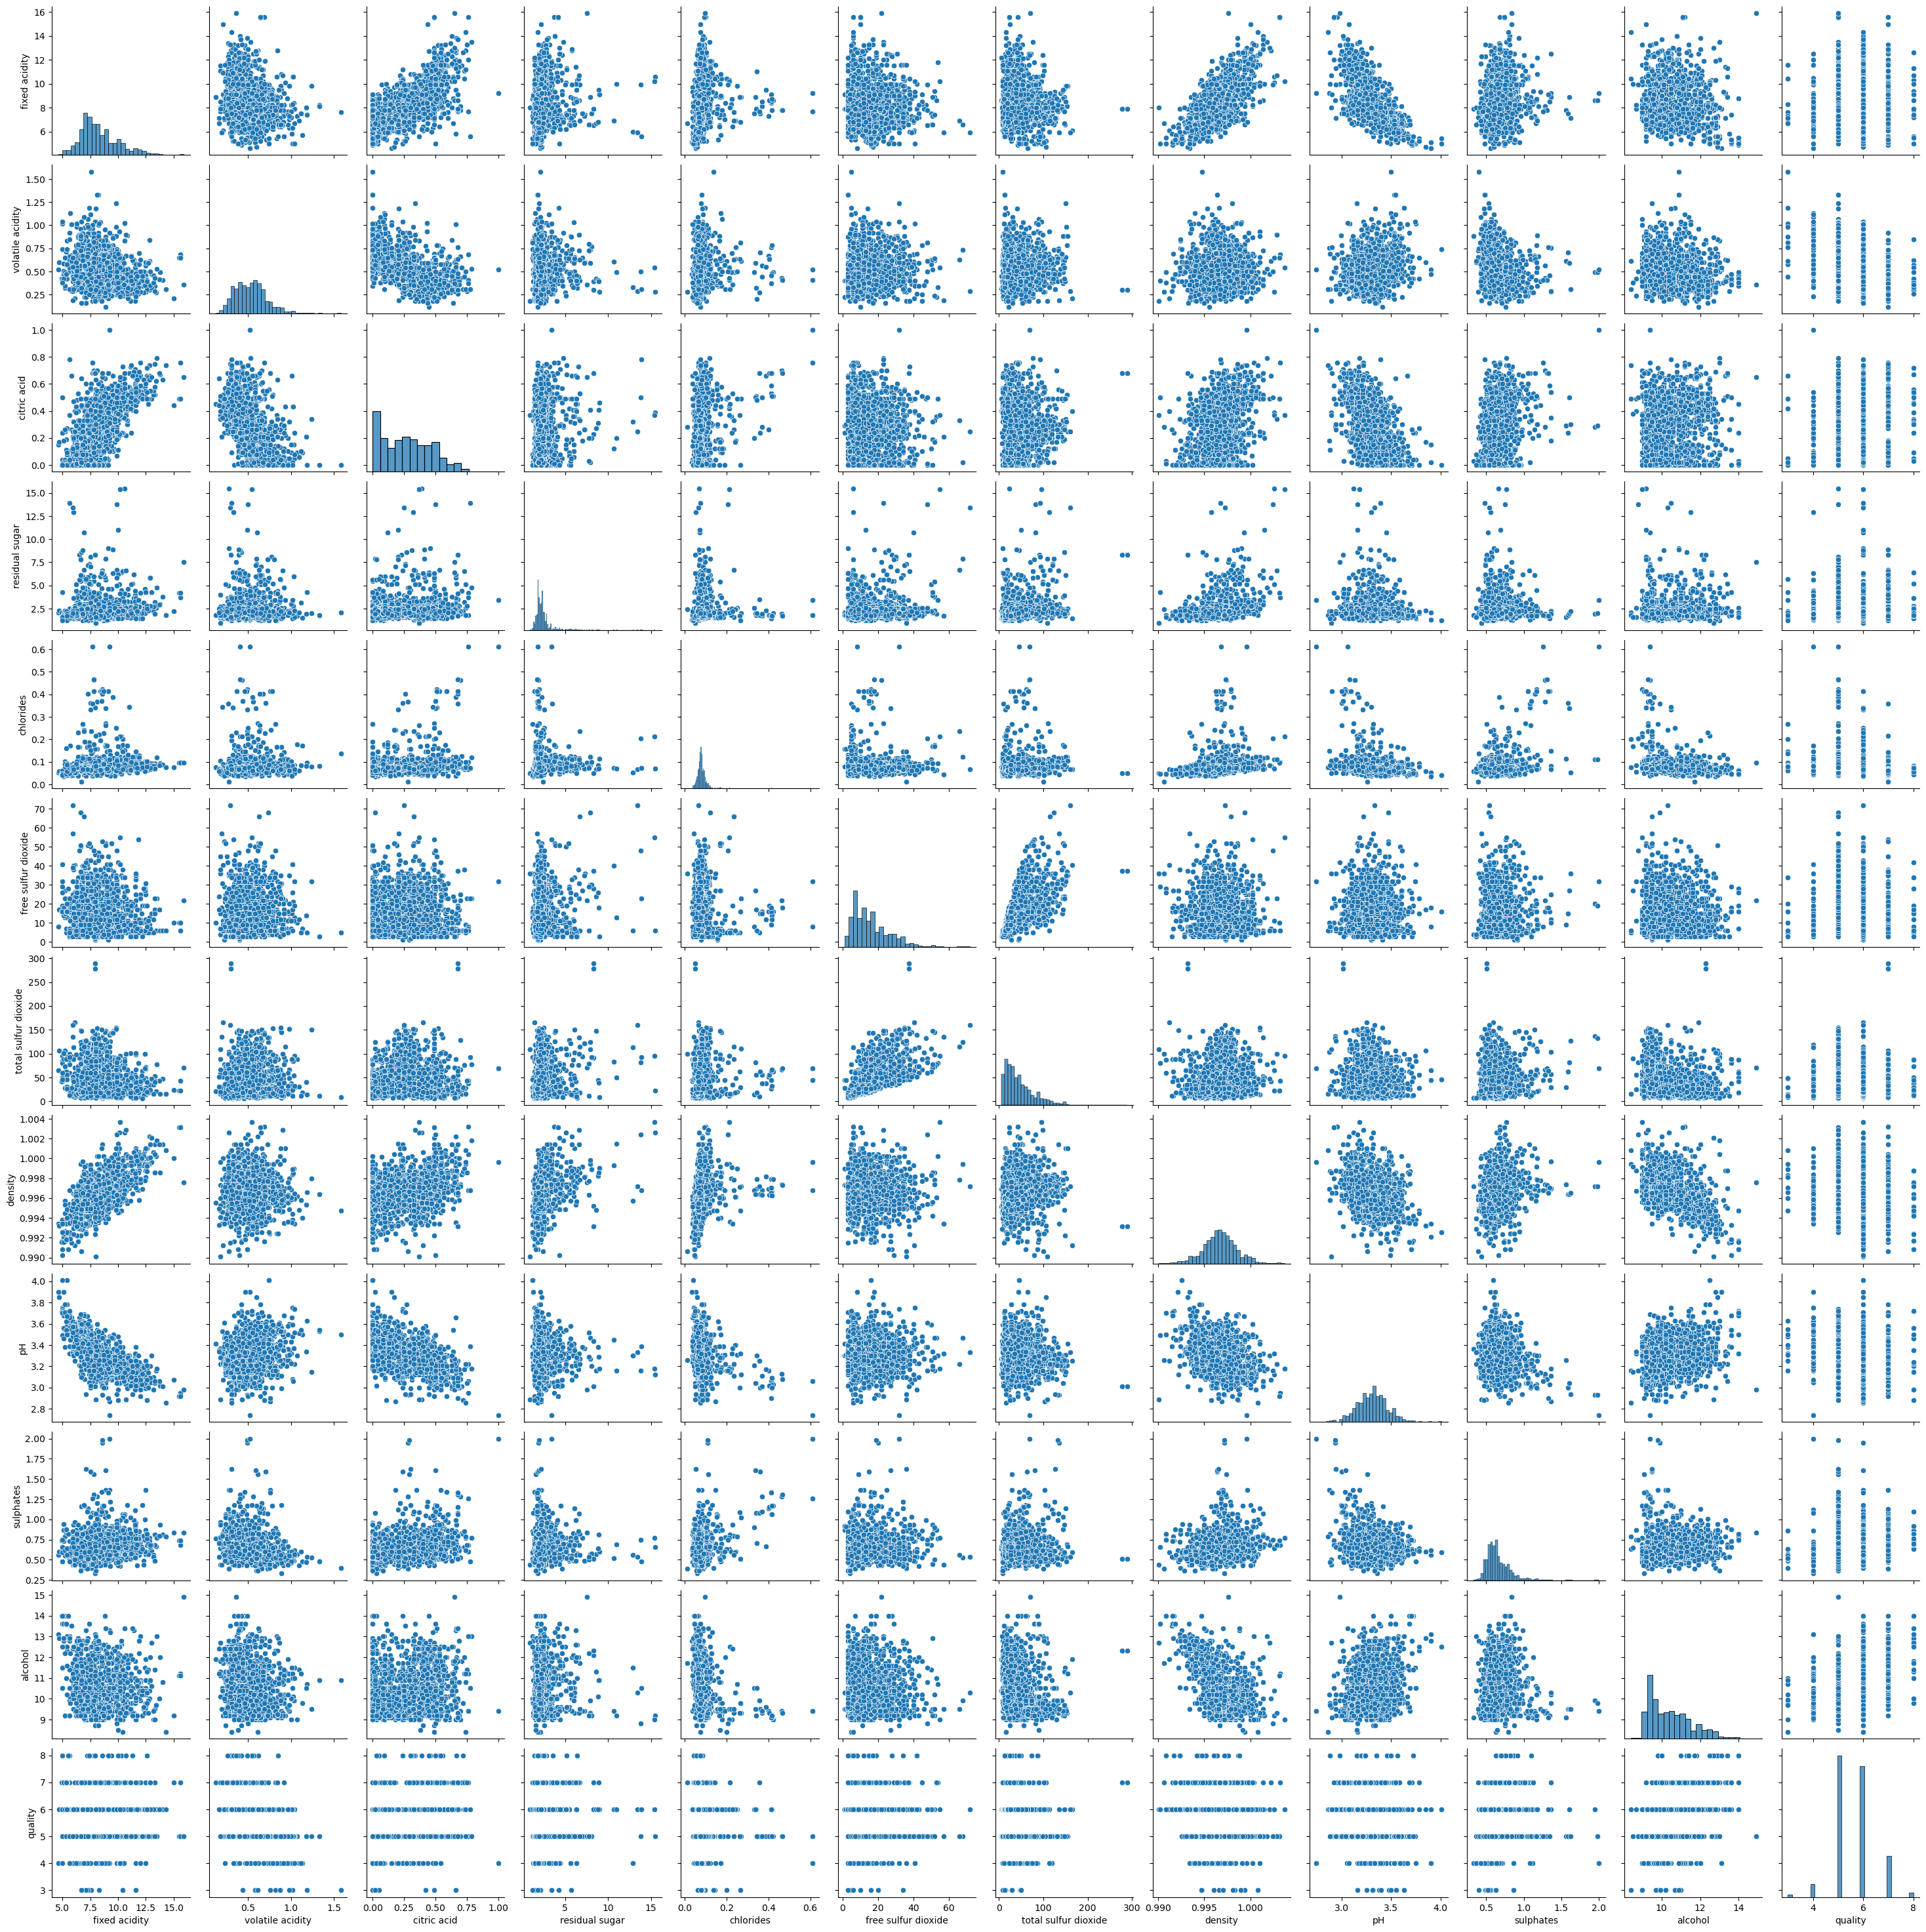

In [47]:
sns.pairplot(df)
plt.show()